In [8]:
# ============================================
# ASSIGNMENT 4
# Applied Statistical Modeling & Interactive Web Dashboard
# Dataset: Medical Insurance Costs
# ============================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical libraries
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, f_oneway

# Load dataset
df = pd.read_csv("insurance.csv")

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Dataset shape
print("\nDataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dataset Shape: (1338, 7)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
# ============================================
# PART 1.1 - BASIC DATASET INFORMATION
# ============================================

# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

Number of rows: 1338
Number of columns: 7

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of Duplicate Rows:
1

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
# ============================================
# PART 1.2 - NUMERICAL AND CATEGORICAL FEATURES
# ============================================

# Numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical columns
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'bmi', 'children', 'charges']

Categorical Columns:
['sex', 'smoker', 'region']


In [11]:
# ============================================
# PART 1.3 - DESCRIPTIVE STATISTICS
# ============================================

descriptive_stats = pd.DataFrame()

for column in numerical_columns:

    mean_value = df[column].mean()
    median_value = df[column].median()
    std_value = df[column].std()

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    skewness = df[column].skew()
    kurtosis = df[column].kurtosis()

    descriptive_stats.loc[column, "Mean"] = mean_value
    descriptive_stats.loc[column, "Median"] = median_value
    descriptive_stats.loc[column, "Standard Deviation"] = std_value
    descriptive_stats.loc[column, "IQR"] = iqr
    descriptive_stats.loc[column, "Skewness"] = skewness
    descriptive_stats.loc[column, "Kurtosis"] = kurtosis

display(descriptive_stats.round(3))

,Mean,Median,Standard Deviation,IQR,Skewness,Kurtosis
age,39.207,39.000,14.050,24.000,0.056,-1.245
bmi,30.663,30.400,6.098,8.398,0.284,-0.051
children,1.095,1.000,1.205,2.000,0.938,0.202
charges,13270.422,9382.033,12110.011,11899.625,1.516,1.606


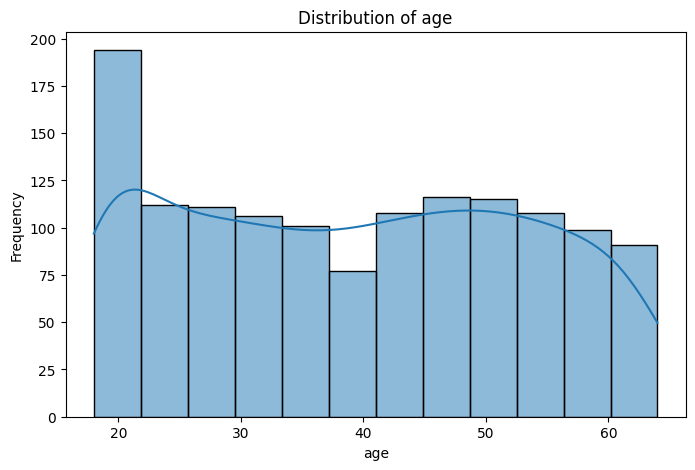

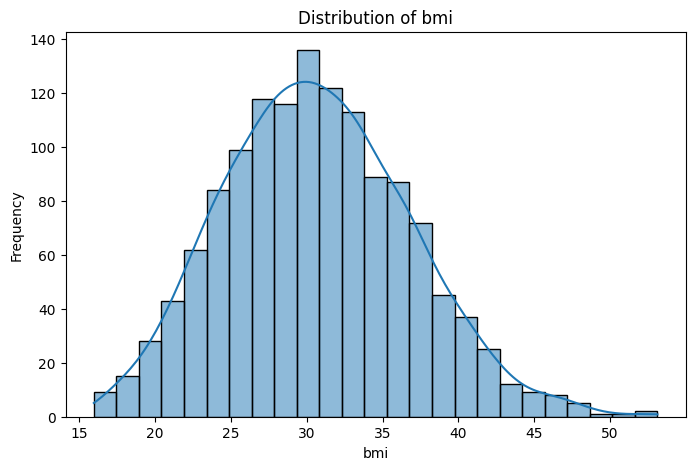

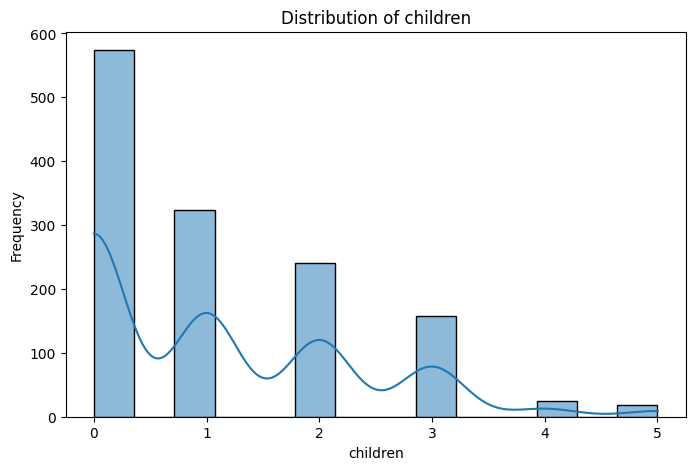

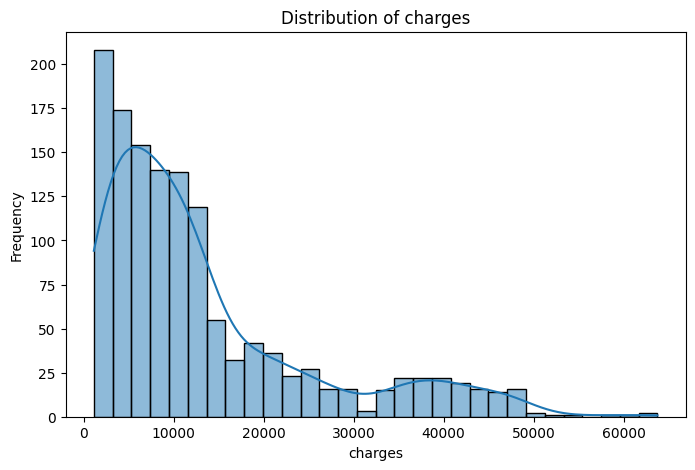

In [12]:
# ============================================
# PART 1.4 - DISTRIBUTION PLOTS
# ============================================

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

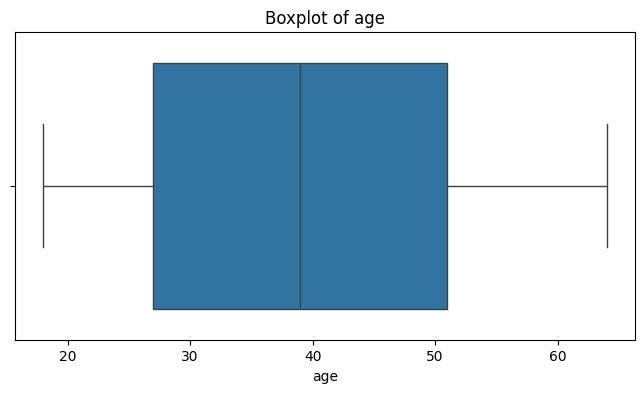

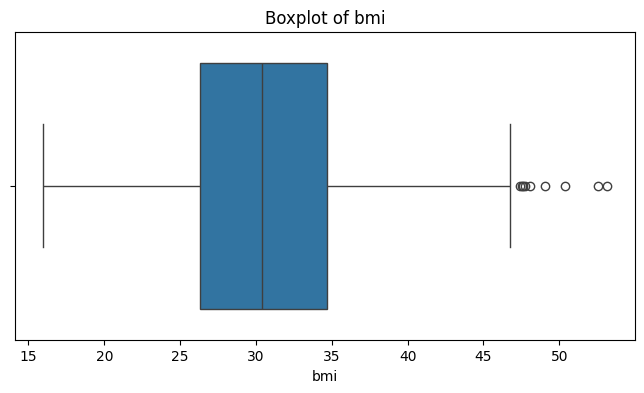

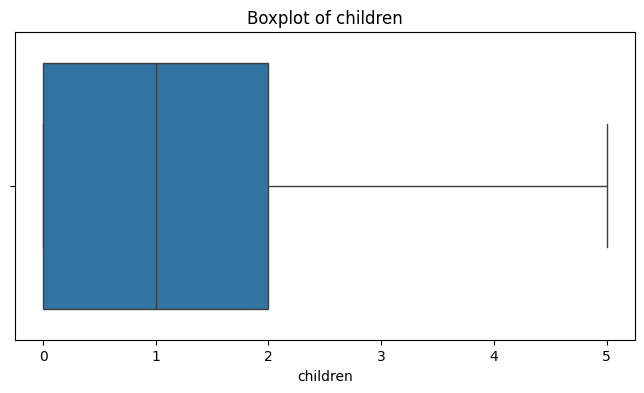

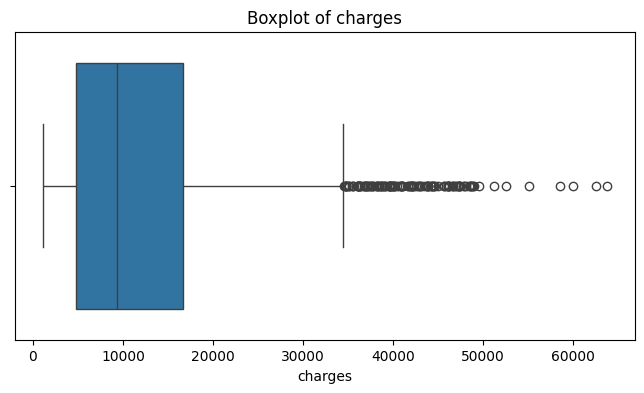

In [13]:
# ============================================
# PART 1.5 - BOXPLOTS
# ============================================

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

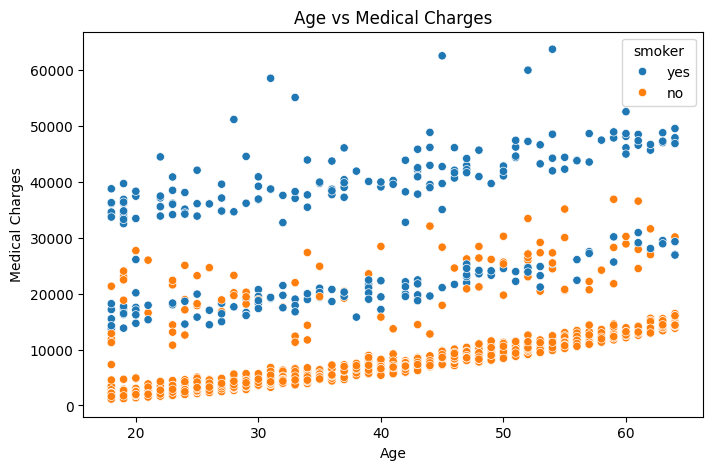

In [14]:
# ============================================
# PART 1.6 - SCATTER PLOTS
# ============================================

# Age vs Charges
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.show()

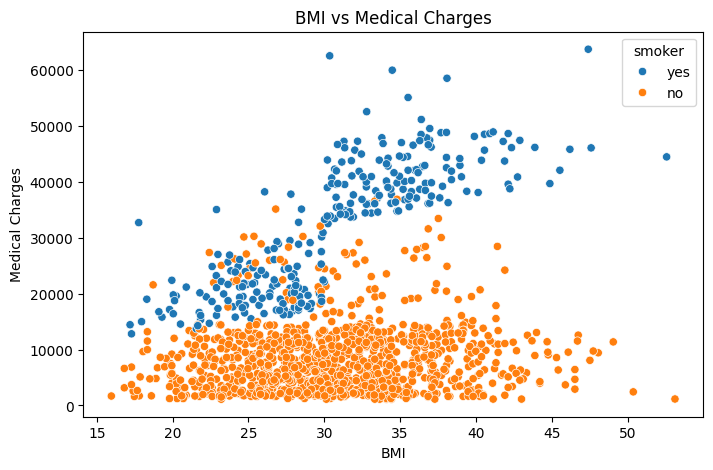

In [15]:
# BMI vs Charges
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")

plt.show()

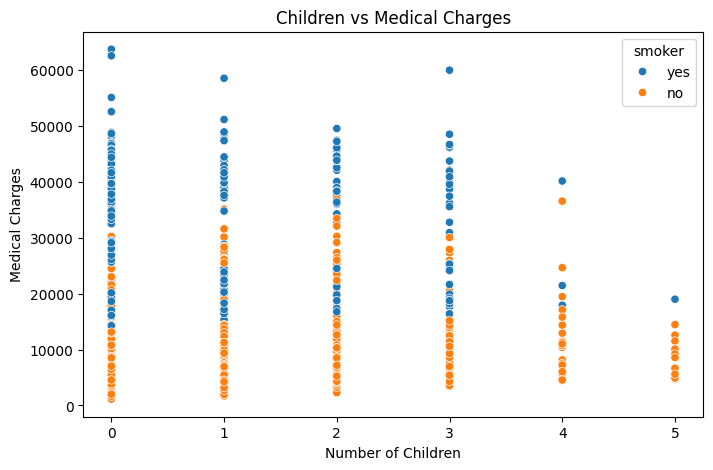

In [16]:
# Children vs Charges
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="children",
    y="charges",
    hue="smoker"
)

plt.title("Children vs Medical Charges")
plt.xlabel("Number of Children")
plt.ylabel("Medical Charges")

plt.show()

Correlation Matrix:


,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


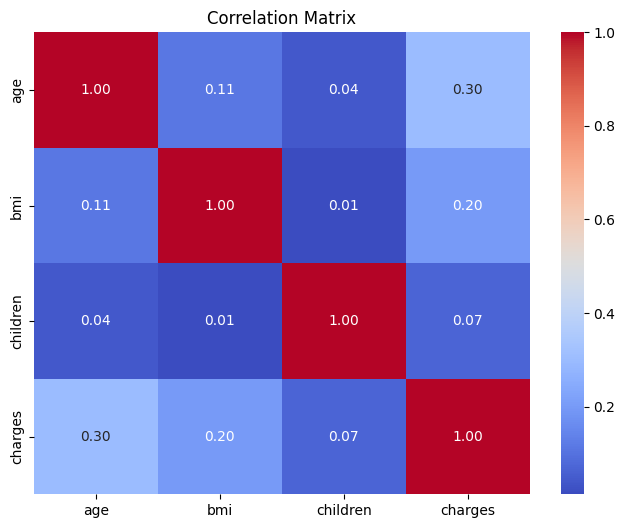

In [17]:
# ============================================
# PART 1.7 - CORRELATION MATRIX
# ============================================

correlation_matrix = df[numerical_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


Value Counts for sex:
sex
male      676
female    662
Name: count, dtype: int64


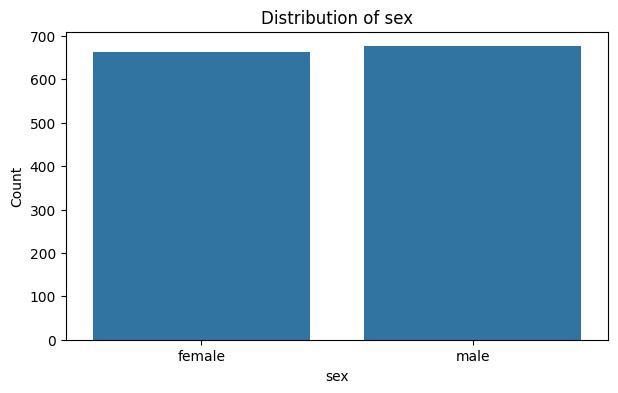


Value Counts for smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64


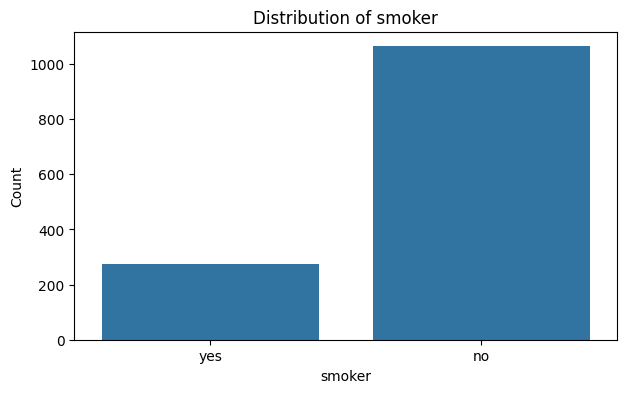


Value Counts for region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


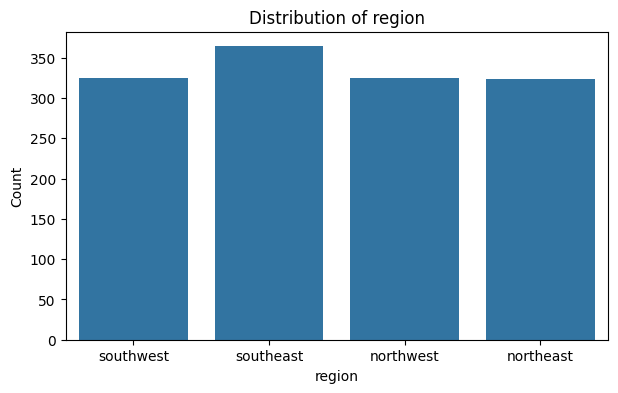

In [18]:
# ============================================
# PART 1.8 - CATEGORICAL VARIABLE DISTRIBUTION
# ============================================

for column in categorical_columns:

    print(f"\nValue Counts for {column}:")
    print(df[column].value_counts())

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

In [19]:
# ============================================
# PART 2.1 - CREATE TWO GROUPS
# ============================================

smokers = df[df["smoker"] == "yes"]["charges"]

non_smokers = df[df["smoker"] == "no"]["charges"]

print("Number of Smokers:", len(smokers))
print("Number of Non-Smokers:", len(non_smokers))

print("\nMean Charges - Smokers:",
      smokers.mean())

print("Mean Charges - Non-Smokers:",
      non_smokers.mean())

Number of Smokers: 274
Number of Non-Smokers: 1064

Mean Charges - Smokers: 32050.23183153284
Mean Charges - Non-Smokers: 8434.268297856204


In [20]:
# ============================================
# PART 2.2 - SHAPIRO-WILK NORMALITY TEST
# ============================================

alpha = 0.05

# Shapiro test
shapiro_smokers = shapiro(smokers)
shapiro_non_smokers = shapiro(non_smokers)

print("Shapiro-Wilk Test - Smokers")
print("Statistic:", shapiro_smokers.statistic)
print("p-value:", shapiro_smokers.pvalue)

print("\nShapiro-Wilk Test - Non-Smokers")
print("Statistic:", shapiro_non_smokers.statistic)
print("p-value:", shapiro_non_smokers.pvalue)

if shapiro_smokers.pvalue > alpha:
    print("\nSmokers: Data appears normally distributed.")
else:
    print("\nSmokers: Data does not appear normally distributed.")

if shapiro_non_smokers.pvalue > alpha:
    print("Non-Smokers: Data appears normally distributed.")
else:
    print("Non-Smokers: Data does not appear normally distributed.")

Shapiro-Wilk Test - Smokers
Statistic: 0.9395519386965634
p-value: 3.6249900590074145e-09

Shapiro-Wilk Test - Non-Smokers
Statistic: 0.8728637657160003
p-value: 1.4459006706130622e-28

Smokers: Data does not appear normally distributed.
Non-Smokers: Data does not appear normally distributed.


In [21]:
# ============================================
# PART 2.3 - LEVENE'S TEST
# ============================================

levene_test = levene(
    smokers,
    non_smokers
)

print("Levene's Test")
print("Statistic:", levene_test.statistic)
print("p-value:", levene_test.pvalue)

if levene_test.pvalue > alpha:
    print("\nVariances can be considered equal.")
else:
    print("\nVariances are significantly different.")

Levene's Test
Statistic: 332.6135162726081
p-value: 1.5593284881803726e-66

Variances are significantly different.


In [22]:
# ============================================
# PART 2.4 - SELECT AND PERFORM TEST
# ============================================

normal_smokers = shapiro_smokers.pvalue > alpha
normal_non_smokers = shapiro_non_smokers.pvalue > alpha

if normal_smokers and normal_non_smokers:

    # Two-sample t-test
    equal_variance = levene_test.pvalue > alpha

    test_result = ttest_ind(
        smokers,
        non_smokers,
        equal_var=equal_variance
    )

    test_name = "Independent Two-Sample t-test"

else:

    # Mann-Whitney U test
    test_result = mannwhitneyu(
        smokers,
        non_smokers,
        alternative="two-sided"
    )

    test_name = "Mann-Whitney U test"


print("Test Used:", test_name)
print("Test Statistic:", test_result.statistic)
print("p-value:", test_result.pvalue)

Test Used: Mann-Whitney U test
Test Statistic: 284133.0
p-value: 5.270233444503571e-130


In [23]:
# ============================================
# PART 2.5 - HYPOTHESIS TEST CONCLUSION
# ============================================

print("Significance Level (α):", alpha)

if test_result.pvalue < alpha:

    print("\nDecision: Reject H0")
    print(
        "Conclusion: There is a statistically significant "
        "difference in medical charges between smokers "
        "and non-smokers."
    )

else:

    print("\nDecision: Fail to Reject H0")
    print(
        "Conclusion: There is insufficient evidence to conclude "
        "that medical charges differ significantly between "
        "smokers and non-smokers."
    )

Significance Level (α): 0.05

Decision: Reject H0
Conclusion: There is a statistically significant difference in medical charges between smokers and non-smokers.


In [24]:
# ============================================
# PART 3.1 - GROUP BY REGION
# ============================================

region_groups = []

for region in df["region"].unique():

    charges = df[
        df["region"] == region
    ]["charges"]

    region_groups.append(charges)

    print(
        f"{region}: "
        f"n = {len(charges)}, "
        f"Mean = {charges.mean():.2f}"
    )

southwest: n = 325, Mean = 12346.94
southeast: n = 364, Mean = 14735.41
northwest: n = 325, Mean = 12417.58
northeast: n = 324, Mean = 13406.38


In [25]:
# ============================================
# PART 3.2 - ONE-WAY ANOVA
# ============================================

anova_result = f_oneway(
    *region_groups
)

print("One-Way ANOVA")
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

One-Way ANOVA
F-statistic: 2.96962669358912
p-value: 0.0308933560705201


In [26]:
# ============================================
# PART 3.3 - ANOVA CONCLUSION
# ============================================

if anova_result.pvalue < alpha:

    print("Decision: Reject H0")

    print(
        "Conclusion: There is a statistically significant "
        "difference in mean medical charges among the regions."
    )

else:

    print("Decision: Fail to Reject H0")

    print(
        "Conclusion: There is insufficient evidence to conclude "
        "that mean medical charges differ among the regions."
    )

Decision: Reject H0
Conclusion: There is a statistically significant difference in mean medical charges among the regions.


In [27]:
# ============================================
# HYPOTHESIS TEST - CHI-SQUARE TEST
# Smoking Status vs Region
# ============================================

import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df["smoker"],
    df["region"]
)

print("Contingency Table:")
display(contingency_table)

# Perform Chi-Square test
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

# Display results
print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", degrees_of_freedom)
print("p-value:", p_value)

# Expected frequencies
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected Frequencies:")
display(expected_table.round(2))

Contingency Table:


region,northeast,northwest,southeast,southwest
smoker,,,,
no,257,267,273,267
yes,67,58,91,58


Chi-Square Statistic: 7.34347776140707
Degrees of Freedom: 3
p-value: 0.06171954839170547

Expected Frequencies:


region,northeast,northwest,southeast,southwest
smoker,,,,
no,257.65,258.45,289.46,258.45
yes,66.35,66.55,74.54,66.55


In [28]:
# ============================================
# CHI-SQUARE TEST CONCLUSION
# ============================================

alpha = 0.05

print("Significance Level (α):", alpha)

if p_value < alpha:

    print("\nDecision: Reject H0")

    print(
        "Conclusion: There is a statistically significant "
        "association between smoking status and region."
    )

else:

    print("\nDecision: Fail to Reject H0")

    print(
        "Conclusion: There is insufficient evidence to conclude "
        "that smoking status and region are associated."
    )

Significance Level (α): 0.05

Decision: Fail to Reject H0
Conclusion: There is insufficient evidence to conclude that smoking status and region are associated.


In [29]:
# ============================================
# PART 4.1 - PREPARE DATA FOR OLS
# ============================================

# Create dummy variables
df_model = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

print("Columns after encoding:")
print(df_model.columns.tolist())

display(df_model.head())

Columns after encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [30]:
# ============================================
# PART 4.2 - DEFINE DEPENDENT AND INDEPENDENT VARIABLES
# ============================================

# Dependent variable
y = df_model["charges"]

# Independent variables
X = df_model.drop(
    columns=["charges"]
)

# Add intercept
import statsmodels.api as sm

X = sm.add_constant(X)

print("Independent Variables:")
print(X.columns.tolist())

print("\nDependent Variable:")
print("charges")

Independent Variables:
['const', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Dependent Variable:
charges


In [31]:
# ============================================
# PART 4.3 - FIT OLS REGRESSION MODEL
# ============================================

ols_model = sm.OLS(
    y,
    X
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:30:45   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

In [32]:
# ============================================
# PART 4.4 - MODEL COEFFICIENTS
# ============================================

coefficients = pd.DataFrame({
    "Coefficient": ols_model.params,
    "P-value": ols_model.pvalues,
    "Lower 95% CI": ols_model.conf_int()[0],
    "Upper 95% CI": ols_model.conf_int()[1]
})

display(coefficients.round(4))

,Coefficient,P-value,Lower 95% CI,Upper 95% CI
const,-11938.5386,0.0000,-13876.3934,-10000.6837
age,256.8564,0.0000,233.5138,280.1989
bmi,339.1935,0.0000,283.0884,395.2985
children,475.5005,0.0006,205.1633,745.8378
sex_male,-131.3144,0.6933,-784.4703,521.8416
smoker_yes,23848.5345,0.0000,23038.0307,24659.0384
region_northwest,-352.9639,0.4588,-1287.2982,581.3704
region_southeast,-1035.0220,0.0308,-1974.0968,-95.9473
region_southwest,-960.0510,0.0448,-1897.6364,-22.4656


In [33]:
# ============================================
# PART 4.5 - MODEL FIT
# ============================================

print("R-squared:", ols_model.rsquared)

print(
    "Adjusted R-squared:",
    ols_model.rsquared_adj
)

R-squared: 0.7509130345985207
Adjusted R-squared: 0.7494136397729286


In [34]:
# ============================================
# PART 4.6 - SIGNIFICANT PREDICTORS
# ============================================

significant_predictors = coefficients[
    coefficients["P-value"] < 0.05
]

print("Statistically Significant Predictors:")
display(significant_predictors.round(4))

Statistically Significant Predictors:


,Coefficient,P-value,Lower 95% CI,Upper 95% CI
const,-11938.5386,0.0000,-13876.3934,-10000.6837
age,256.8564,0.0000,233.5138,280.1989
bmi,339.1935,0.0000,283.0884,395.2985
children,475.5005,0.0006,205.1633,745.8378
smoker_yes,23848.5345,0.0000,23038.0307,24659.0384
region_southeast,-1035.0220,0.0308,-1974.0968,-95.9473
region_southwest,-960.0510,0.0448,-1897.6364,-22.4656


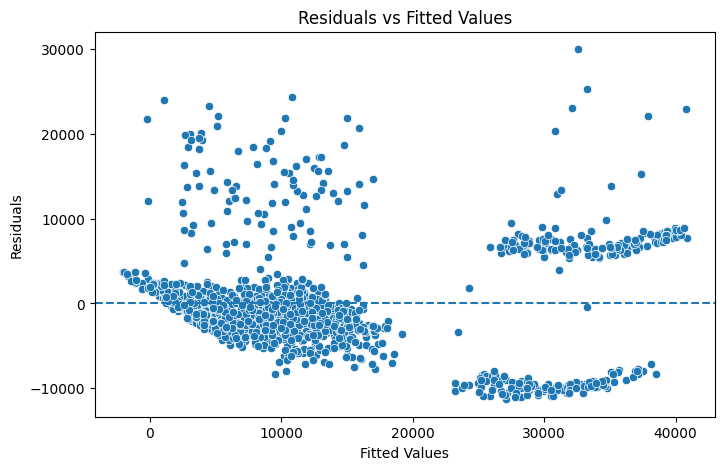

In [35]:
# ============================================
# PART 5.1 - RESIDUALS VS FITTED
# ============================================

fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

<Figure size 700x600 with 0 Axes>

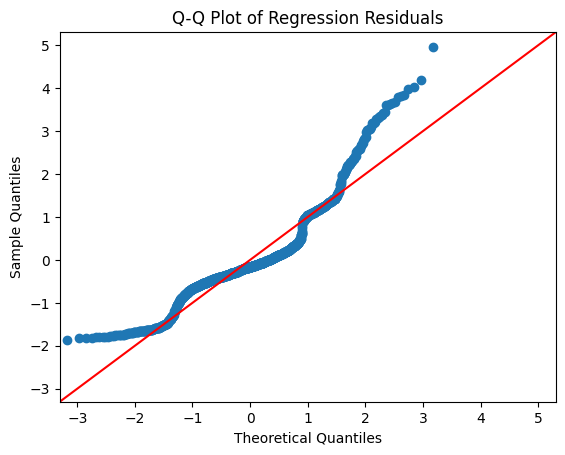

In [36]:
# ============================================
# PART 5.2 - Q-Q PLOT
# ============================================

import statsmodels.api as sm

plt.figure(figsize=(7, 6))

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Regression Residuals")

plt.show()

In [37]:
# ============================================
# PART 5.3 - JARQUE-BERA TEST
# ============================================

from scipy.stats import jarque_bera

jb_test = jarque_bera(residuals)

print("Jarque-Bera Statistic:",
      jb_test.statistic)

print("Jarque-Bera p-value:",
      jb_test.pvalue)

if jb_test.pvalue > 0.05:

    print(
        "\nResiduals do not show significant "
        "evidence of non-normality."
    )

else:

    print(
        "\nResiduals show significant evidence "
        "of non-normality."
    )

Jarque-Bera Statistic: 718.887263570793
Jarque-Bera p-value: 7.863468661813022e-157

Residuals show significant evidence of non-normality.


In [38]:
# ============================================
# PART 5.4 - VARIANCE INFLATION FACTOR (VIF)
# ============================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove constant for VIF calculation
X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

display(vif_data.round(3))

,Feature,VIF
0,age,1.017
1,bmi,1.107
2,children,1.004
3,sex_male,1.009
4,smoker_yes,1.012
5,region_northwest,1.519
6,region_southeast,1.652
7,region_southwest,1.529


In [39]:
# ============================================
# PART 5.5 - VIF INTERPRETATION
# ============================================

for _, row in vif_data.iterrows():

    feature = row["Feature"]
    vif = row["VIF"]

    if vif < 5:

        interpretation = "Low multicollinearity"

    elif vif < 10:

        interpretation = "Moderate multicollinearity"

    else:

        interpretation = "High multicollinearity"

    print(
        f"{feature}: VIF = {vif:.3f} → {interpretation}"
    )

age: VIF = 1.017 → Low multicollinearity
bmi: VIF = 1.107 → Low multicollinearity
children: VIF = 1.004 → Low multicollinearity
sex_male: VIF = 1.009 → Low multicollinearity
smoker_yes: VIF = 1.012 → Low multicollinearity
region_northwest: VIF = 1.519 → Low multicollinearity
region_southeast: VIF = 1.652 → Low multicollinearity
region_southwest: VIF = 1.529 → Low multicollinearity


In [40]:
# ============================================
# PART 6 - SAVE RESULTS
# ============================================

# Save descriptive statistics
descriptive_stats.to_csv(
    "descriptive_statistics.csv"
)

# Save regression coefficients
coefficients.to_csv(
    "regression_coefficients.csv"
)

# Save VIF results
vif_data.to_csv(
    "vif_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
